<a href="https://colab.research.google.com/github/hostlogic1/3-Simple-Python-Projects/blob/master/KST_EMA_Strategy_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📈 Know Sure Thing (KST) + EMA — Multi-Timeframe Strategy
### With HMM Regime Detection · Random Forest Optimization · Full Backtesting

---
**Timeframes:** Signal = `5m` / `15m` &nbsp;|&nbsp; Key Levels = `1hr` pivots  
**ML Stack:** HMM Market Regime · Random Forest (Optuna-optimised)  
**Optimises:** FastEMA, SlowEMA, RSI window — 100–400 trials  
**Platform:** Runs locally or on ☁️ Google Colab  

---


In [10]:
# ── Install dependencies (auto-detects Colab vs local) ────────────────────────
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

PACKAGES = [
    "yfinance",
    "pandas",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "hmmlearn",
    "optuna",
    "ta",           # Technical Analysis library
    "seaborn",
]

print("Installing packages …")
for p in PACKAGES:
    install(p)
print("✅ All packages ready.")


Installing packages …
✅ All packages ready.


In [11]:
import warnings
warnings.filterwarnings("ignore")

import numpy  as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot  as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from dataclasses import dataclass, field
from typing      import Optional, Tuple

# Indicators
import ta

# ML
from sklearn.ensemble        import RandomForestClassifier
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics         import classification_report, confusion_matrix
from hmmlearn                import hmm

# Pretty prints
pd.set_option("display.float_format", "{:.4f}".format)
print("✅ Imports complete.")


✅ Imports complete.


## ⚙️ Configuration — Edit Your Settings Here

In [17]:
# ╔═══════════════════════════════════════════════════╗
# ║              STRATEGY CONFIGURATION                         ║
# ╚═══════════════════════════════════════════════════╝

# ── Asset & Date Range ─────────────────────────
import datetime
TICKER          = "BTC-USD"          # Any yfinance-compatible ticker
# Set end date to a fixed recent past date to workaround Colab's datetime.date.today() issue and yfinance's future date restriction
END_DATE        = "2024-01-25" # Set to a fixed recent past date
START_DATE      = (datetime.datetime.strptime(END_DATE, '%Y-%m-%d') - datetime.timedelta(days=60)).strftime('%Y-%m-%d')

# ── Timeframes ────────────────────────
SIGNAL_TF       = "5m"             # Signal timeframe  : "5m" or "15m"
PIVOT_TF        = "1h"              # Key-level timeframe: "1h"

# ── KST Settings ─────────────────────────
@dataclass
class KSTParams:
    roc1_len: int = 10
    roc2_len: int = 15
    roc3_len: int = 20
    roc4_len: int = 30
    sma1_len: int = 10
    sma2_len: int = 15
    sma3_len: int = 20
    sma4_len: int = 30
    sig_len:  int = 20

KST_PARAMS = KSTParams()

# ── EMA Regime ────────────────────────
EMA_SLOW    = 200          # Baseline regime EMA (mirrors PineScript)

# ── RF Optimisation Search Space ───────────────────────
FAST_EMA_MIN    = 5
FAST_EMA_MAX    = 50
SLOW_EMA_MIN    = 50
SLOW_EMA_MAX    = 200
RSI_MIN         = 7
RSI_MAX         = 21
N_OPTUNA_TRIALS = 150      # 100-400 — increase for deeper search

# ── HMM ─────────────────────────
HMM_N_STATES    = 3        # 2 = Bull/Bear | 3 = Bull/Bear/Ranging | 4 = fine-grained
HMM_COVAR_TYPE  = "full"   # "full" | "diag" | "spherical"

# ── Backtest ─────────────────────────
@dataclass
class BacktestParams:
    initial_capital:  float = 10_000.0
    position_size_pct:float = 1.0       # 1.0 = 100% of capital per trade
    commission_pct:   float = 0.001     # 0.1% per side
    slippage_pct:     float = 0.0005    # 0.05% per side

BT_PARAMS = BacktestParams()

print("✅ Configuration loaded.")
print(f"   Ticker : {TICKER}  |  Signal TF: {SIGNAL_TF}  |  Pivot TF: {PIVOT_TF}")
print(f"   Dates  : {START_DATE} → {END_DATE}")
print(f"   Optuna : {N_OPTUNA_TRIALS} trials  |  HMM States: {HMM_N_STATES}")


✅ Configuration loaded.
   Ticker : BTC-USD  |  Signal TF: 5m  |  Pivot TF: 1h
   Dates  : 2023-11-26 → 2024-01-25
   Optuna : 150 trials  |  HMM States: 3


## 📥 Data Download — Multi-Timeframe

In [20]:
def download_ohlcv(ticker: str, start: str = None, end: str = None, interval: str = None) -> pd.DataFrame:
    """Download and clean OHLCV from yfinance."""
    # yfinance caps intraday history: 60d for 1m, 730d for 5m/15m/1h
    # For intraday intervals, using 'period' is more reliable for 'last N days'
    if interval.endswith('m') or interval.endswith('h'):
        # Use 'period' for intraday intervals to get max available history (60 days for 5m/15m/1h)
        raw = yf.download(ticker, period='60d', interval=interval, auto_adjust=True, progress=False)
    else:
        raw = yf.download(ticker, start=start, end=end, interval=interval, auto_adjust=True, progress=False)

    if raw.empty:
        raise ValueError(f"No data for {ticker} @ {interval}. "
                         "Check date range — yfinance limits intraday history to ~2 years.")
    df = raw[["Open","High","Low","Close","Volume"]].copy()
    df.columns = ["open","high","low","close","volume"]
    # Flatten MultiIndex if present
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df.dropna(inplace=True)
    df.index = pd.to_datetime(df.index)
    # Normalise timezone → UTC naive
    if df.index.tz is not None:
        df.index = df.index.tz_localize(None)
    return df


print(f"Downloading {TICKER} @ {SIGNAL_TF} …", end="  ")
df_signal = download_ohlcv(TICKER, interval=SIGNAL_TF) # Removed start/end, using period internally
print(f"✅  {len(df_signal):,} bars")

print(f"Downloading {TICKER} @ {PIVOT_TF}  …", end="  ")
df_pivot  = download_ohlcv(TICKER, interval=PIVOT_TF) # Removed start/end, using period internally
print(f"✅  {len(df_pivot):,} bars")

df_signal.tail(3)


,open,high,low,close,volume
Datetime,,,,,
2026-02-22 00:50:00,67838.6875,67864.5312,67838.6875,67847.7734,7000064
2026-02-22 00:55:00,67856.9531,67906.1797,67856.9531,67906.1797,3409920
2026-02-22 01:00:00,67924.0391,67955.7969,67922.8984,67955.7969,4143104


## 📐 Indicator Calculations

In [21]:
# ── KST ──────────────────────────────────────────────────────
def calc_roc(series: pd.Series, length: int) -> pd.Series:
    return 100 * (series - series.shift(length)) / series.shift(length)

def calc_kst(close: pd.Series, p: KSTParams) -> pd.DataFrame:
    r1 = calc_roc(close, p.roc1_len).rolling(p.sma1_len).mean()
    r2 = calc_roc(close, p.roc2_len).rolling(p.sma2_len).mean()
    r3 = calc_roc(close, p.roc3_len).rolling(p.sma3_len).mean()
    r4 = calc_roc(close, p.roc4_len).rolling(p.sma4_len).mean()
    kst_val    = r1 + 2*r2 + 3*r3 + 4*r4
    kst_signal = kst_val.rolling(p.sig_len).mean()
    return pd.DataFrame({
        "kst":        kst_val,
        "kst_signal": kst_signal,
        "kst_hist":   kst_val - kst_signal,
    })


# ── EMA, RSI, ATR ────────────────────────────────────────────
def add_indicators(df: pd.DataFrame,
                   fast_ema: int = 20,
                   slow_ema: int = 200,
                   rsi_len:  int = 14) -> pd.DataFrame:
    df = df.copy()

    # KST
    kst_df = calc_kst(df["close"], KST_PARAMS)
    df = pd.concat([df, kst_df], axis=1)

    # EMAs
    df[f"ema_{fast_ema}"] = df["close"].ewm(span=fast_ema, adjust=False).mean()
    df[f"ema_{slow_ema}"] = df["close"].ewm(span=slow_ema, adjust=False).mean()
    df["ema_fast"]        = df[f"ema_{fast_ema}"]
    df["ema_slow"]        = df[f"ema_{slow_ema}"]

    # RSI
    df["rsi"] = ta.momentum.RSIIndicator(df["close"], window=rsi_len).rsi()

    # ATR
    df["atr"] = ta.volatility.AverageTrueRange(
        df["high"], df["low"], df["close"], window=14).average_true_range()

    # MACD
    macd = ta.trend.MACD(df["close"])
    df["macd"]        = macd.macd()
    df["macd_signal"] = macd.macd_signal()
    df["macd_hist"]   = macd.macd_diff()

    # Bollinger Bands
    bb = ta.volatility.BollingerBands(df["close"], window=20, window_dev=2)
    df["bb_upper"] = bb.bollinger_hband()
    df["bb_lower"] = bb.bollinger_lband()
    df["bb_pct"]   = bb.bollinger_pband()  # % position within bands

    # Regime by EMA_SLOW
    df["bull_regime"] = df["close"] > df["ema_slow"]

    return df


# Apply default indicators to signal timeframe
df_signal = add_indicators(df_signal, fast_ema=20, slow_ema=EMA_SLOW, rsi_len=14)
print(f"✅ Indicators applied to signal TF  —  columns: {list(df_signal.columns)}")
df_signal.tail(3)


✅ Indicators applied to signal TF  —  columns: ['open', 'high', 'low', 'close', 'volume', 'kst', 'kst_signal', 'kst_hist', 'ema_20', 'ema_200', 'ema_fast', 'ema_slow', 'rsi', 'atr', 'macd', 'macd_signal', 'macd_hist', 'bb_upper', 'bb_lower', 'bb_pct', 'bull_regime']


,open,high,low,close,volume,kst,kst_signal,kst_hist,ema_20,ema_200,...,ema_slow,rsi,atr,macd,macd_signal,macd_hist,bb_upper,bb_lower,bb_pct,bull_regime
Datetime,,,,,,,,,,,,,,,,,,,,,
2026-02-22 00:50:00,67838.6875,67864.5312,67838.6875,67847.7734,7000064,5.7663,3.0417,2.7246,67686.4160,67037.2276,...,67037.2276,66.8318,70.0784,162.2534,156.7713,5.4821,68232.8457,67045.8793,0.6756,True
2026-02-22 00:55:00,67856.9531,67906.1797,67856.9531,67906.1797,3409920,5.9473,3.2409,2.7064,67707.3459,67045.8739,...,67045.8739,69.4123,69.2447,159.7943,157.3759,2.4184,68248.2868,67095.9890,0.7031,True
2026-02-22 01:00:00,67924.0391,67955.7969,67922.8984,67955.7969,4143104,6.2025,3.4617,2.7408,67731.0079,67054.9279,...,67054.9279,71.4449,67.8427,160.0047,157.9016,2.1030,68259.2215,67157.8543,0.7245,True


## 🕐 1-Hour Pivot Key Levels
Pivot High/Low levels calculated on the 1hr chart and forward-filled down to the signal timeframe.


In [22]:
def calc_pivot_levels(df_1h: pd.DataFrame, lookback: int = 5) -> pd.DataFrame:
    """
    Detect Swing High / Swing Low pivots on 1hr bars.
    A pivot high = bar[i].high > all bars in ±lookback window.
    Returns DataFrame with pivot_high, pivot_low columns (NaN where no pivot).
    """
    df = df_1h.copy()
    highs = df["high"].values
    lows  = df["low"].values
    n     = len(df)

    pivot_high = np.full(n, np.nan)
    pivot_low  = np.full(n, np.nan)

    for i in range(lookback, n - lookback):
        window_h = highs[i - lookback: i + lookback + 1]
        window_l = lows [i - lookback: i + lookback + 1]
        if highs[i] == window_h.max():
            pivot_high[i] = highs[i]
        if lows[i] == window_l.min():
            pivot_low[i]  = lows[i]

    df["pivot_high"] = pivot_high
    df["pivot_low"]  = pivot_low

    # Forward-fill so every bar carries the last known level
    df["resist"] = df["pivot_high"].ffill()
    df["support"] = df["pivot_low"].ffill()

    return df[["resist","support"]]


# Build pivot levels from 1hr data
df_pivots = calc_pivot_levels(df_pivot, lookback=5)

# ── Merge 1hr pivot levels onto signal TF ────────────────────
def merge_htf_levels(df_lower: pd.DataFrame,
                     df_htf_levels: pd.DataFrame) -> pd.DataFrame:
    """
    Merge higher-timeframe levels onto lower-timeframe bars using
    merge_asof (forward fill the most recent HTF value).
    """
    lower = df_lower.copy().reset_index().rename(columns={"index":"datetime","Datetime":"datetime","Date":"datetime"})
    htf   = df_htf_levels.reset_index().rename(columns={"index":"datetime","Datetime":"datetime","Date":"datetime"})

    # Ensure both are sorted and datetime
    lower["datetime"] = pd.to_datetime(lower["datetime"])
    htf["datetime"]   = pd.to_datetime(htf["datetime"])

    merged = pd.merge_asof(
        lower.sort_values("datetime"),
        htf.sort_values("datetime"),
        on="datetime",
        direction="backward"
    )
    merged.set_index("datetime", inplace=True)
    return merged


df_signal = merge_htf_levels(df_signal, df_pivots)

# Distance from key levels (as % of price)
df_signal["dist_to_resist"] = (df_signal["resist"] - df_signal["close"]) / df_signal["close"] * 100
df_signal["dist_to_support"] = (df_signal["close"] - df_signal["support"]) / df_signal["close"] * 100

# Near key level flags (within 0.5%)
df_signal["near_resist"] = df_signal["dist_to_resist"].abs() < 0.5
df_signal["near_support"] = df_signal["dist_to_support"].abs() < 0.5

print(f"✅ 1hr Pivot levels merged onto {SIGNAL_TF} bars.")
print(f"   Resistance levels found : {df_pivots['resist'].notna().sum()}")
print(f"   Support    levels found : {df_pivots['support'].notna().sum()}")
df_signal[["close","resist","support","dist_to_resist","dist_to_support"]].tail(5)


✅ 1hr Pivot levels merged onto 5m bars.
   Resistance levels found : 1359
   Support    levels found : 1364


,close,resist,support,dist_to_resist,dist_to_support
datetime,,,,,
2026-02-22 00:40:00,67863.6484,67247.7188,65672.1250,-0.9076,3.2293
2026-02-22 00:45:00,67861.0703,67247.7188,65672.1250,-0.9038,3.2256
2026-02-22 00:50:00,67847.7734,67247.7188,65672.1250,-0.8844,3.2067
2026-02-22 00:55:00,67906.1797,67247.7188,65672.1250,-0.9697,3.2899
2026-02-22 01:00:00,67955.7969,67247.7188,65672.1250,-1.0420,3.3605


## 🤖 HMM — Hidden Markov Model Regime Detection
Fits a Gaussian HMM on returns, volatility, and volume features to identify hidden market states  
(e.g. **Trending Bull**, **Trending Bear**, **Ranging/Choppy**).


In [23]:
class HMMRegimeDetector:
    """
    Gaussian HMM that learns latent market states from price/vol features.
    States are auto-labelled by mean return (ascending → 0=Bear … N=Bull).
    """

    def __init__(self, n_states: int = 3, covariance_type: str = "full",
                 n_iter: int = 200, random_state: int = 42):
        self.n_states  = n_states
        self.model     = hmm.GaussianHMM(
            n_components    = n_states,
            covariance_type = covariance_type,
            n_iter          = n_iter,
            random_state    = random_state,
        )
        self.scaler    = StandardScaler()
        self.state_map = {}     # raw state → labelled state
        self.fitted    = False

    def _build_obs(self, df: pd.DataFrame) -> np.ndarray:
        """Build observation matrix for HMM fitting/inference."""
        feats = pd.DataFrame({
            "log_ret":   np.log(df["close"] / df["close"].shift(1)),
            "vol_5":     np.log(df["close"] / df["close"].shift(1)).rolling(5).std(),
            "vol_20":    np.log(df["close"] / df["close"].shift(1)).rolling(20).std(),
            "rsi_norm":  (df["rsi"] - 50) / 50  if "rsi" in df.columns else pd.Series(0, index=df.index),
            "atr_norm":  df["atr"] / df["close"] if "atr" in df.columns else pd.Series(0, index=df.index),
        })
        feats.dropna(inplace=True)
        return feats, self.scaler.fit_transform(feats) if not self.fitted                else self.scaler.transform(feats)

    def fit(self, df: pd.DataFrame) -> "HMMRegimeDetector":
        feats_df, obs = self._build_obs(df)
        self.fit_index = feats_df.index
        self.model.fit(obs)
        raw_states = self.model.predict(obs)

        # Label states by mean log-return (ascending: 0=most bearish → N=most bullish)
        mean_rets = {s: np.mean(np.log(df.loc[self.fit_index]["close"] /
                                       df.loc[self.fit_index]["close"].shift(1))
                                [raw_states == s])
                     for s in range(self.n_states)}
        sorted_states = sorted(mean_rets, key=mean_rets.get)
        self.state_map = {raw: rank for rank, raw in enumerate(sorted_states)}
        self.fitted = True
        print(f"   HMM fitted — state mean returns: "
              f"{[f'S{self.state_map[s]}={mean_rets[s]:.5f}' for s in range(self.n_states)]}")
        return self

    def predict(self, df: pd.DataFrame) -> pd.Series:
        """Returns integer Series aligned to df index (0=most bearish, N-1=most bullish)."""
        feats_df, obs = self._build_obs(df)
        raw = self.model.predict(obs)
        labelled = np.array([self.state_map[s] for s in raw])
        return pd.Series(labelled, index=feats_df.index, name="hmm_state")

    def predict_proba(self, df: pd.DataFrame) -> pd.DataFrame:
        """Returns state probability matrix."""
        feats_df, obs = self._build_obs(df)
        proba = self.model.predict_proba(obs)
        cols  = [f"hmm_prob_s{self.state_map[i]}" for i in range(self.n_states)]
        return pd.DataFrame(proba, index=feats_df.index, columns=cols)


# ── Fit HMM ────────────────────────────────────────────────────
print(f"Fitting HMM ({HMM_N_STATES} states) on {SIGNAL_TF} data …")
hmm_detector = HMMRegimeDetector(n_states=HMM_N_STATES,
                                  covariance_type=HMM_COVAR_TYPE)
hmm_detector.fit(df_signal.dropna())

# Add HMM states + probabilities to dataframe
hmm_states  = hmm_detector.predict(df_signal.dropna())
hmm_probas  = hmm_detector.predict_proba(df_signal.dropna())
df_signal   = df_signal.join(hmm_states,  how="left")
df_signal   = df_signal.join(hmm_probas,  how="left")

# Bull-regime from HMM (top half of states = bullish)
bull_threshold = HMM_N_STATES // 2
df_signal["hmm_bull"] = df_signal["hmm_state"] >= bull_threshold

print(f"✅ HMM complete.  Bull threshold: state ≥ {bull_threshold}")
print(df_signal["hmm_state"].value_counts().sort_index()
      .rename(index={i: f"State {i}" for i in range(HMM_N_STATES)}))


Fitting HMM (3 states) on 5m data …
   HMM fitted — state mean returns: ['S0=-0.00003', 'S1=-0.00003', 'S2=0.00000']
✅ HMM complete.  Bull threshold: state ≥ 1
hmm_state
State 0    6572
State 1    3306
State 2    6397
Name: count, dtype: int64


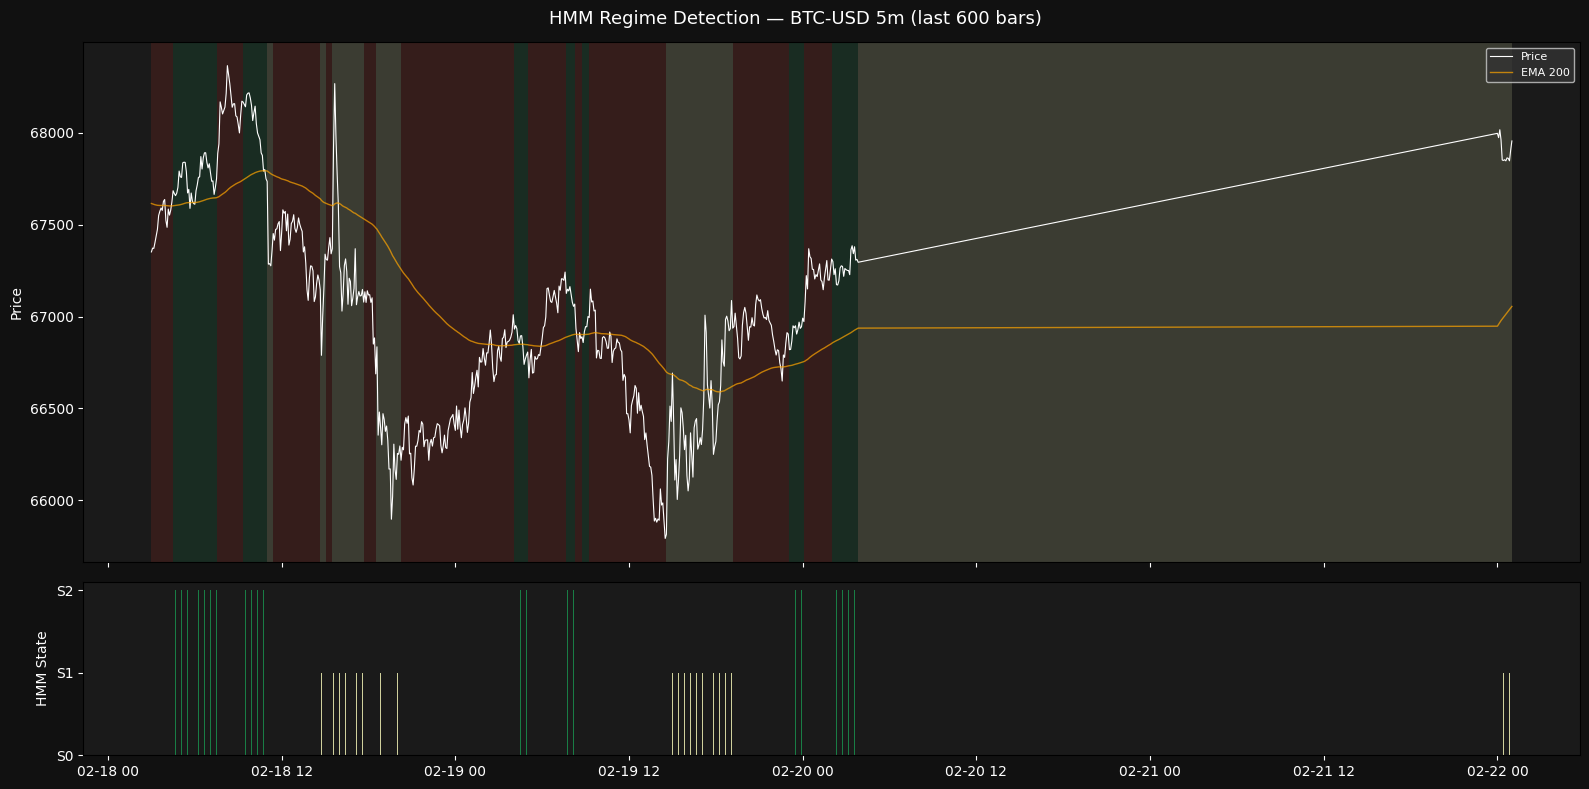

In [24]:
def plot_hmm_regimes(df: pd.DataFrame, n_states: int, sample_bars: int = 500):
    """Visualise HMM states overlaid on price — last N bars for clarity."""
    df_plot = df.dropna(subset=["hmm_state"]).iloc[-sample_bars:]
    palette = plt.cm.RdYlGn(np.linspace(0.1, 0.9, n_states))

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 8), sharex=True,
                                    gridspec_kw={"height_ratios": [3,1]})
    fig.patch.set_facecolor("#111111")
    for ax in (ax1, ax2):
        ax.set_facecolor("#1a1a1a")

    # Price
    ax1.plot(df_plot.index, df_plot["close"], color="white", lw=0.8, label="Price")
    if "ema_slow" in df_plot.columns:
        ax1.plot(df_plot.index, df_plot["ema_slow"], color="orange", lw=1, alpha=0.7,
                 label=f"EMA {EMA_SLOW}")

    # Shade by HMM state
    state_arr = df_plot["hmm_state"].values
    for i in range(1, len(df_plot)):
        s = int(state_arr[i])
        ax1.axvspan(df_plot.index[i-1], df_plot.index[i],
                    color=palette[s], alpha=0.15, linewidth=0)

    ax1.set_ylabel("Price", color="white")
    ax1.legend(facecolor="#333", labelcolor="white", fontsize=8)
    ax1.tick_params(colors="white")

    # HMM state bar
    ax2.bar(df_plot.index, df_plot["hmm_state"], color=[palette[int(s)] for s in state_arr],
            width=0.0005, alpha=0.8)
    ax2.set_ylabel("HMM State", color="white")
    ax2.set_yticks(range(n_states))
    ax2.set_yticklabels([f"S{i}" for i in range(n_states)], color="white")
    ax2.tick_params(colors="white")

    fig.suptitle(f"HMM Regime Detection — {TICKER} {SIGNAL_TF} (last {sample_bars} bars)",
                 color="white", fontsize=13)
    plt.tight_layout()
    plt.savefig("hmm_regimes.png", dpi=130, bbox_inches="tight", facecolor="#111111")
    plt.show()

plot_hmm_regimes(df_signal, HMM_N_STATES, sample_bars=600)


## 📡 Base Signal Generation (KST + EMA Regime)

In [25]:
def generate_kst_signals(df: pd.DataFrame,
                         use_hmm_filter: bool = True) -> pd.DataFrame:
    """
    Mirror PineScript logic:
      Long  : KST crosses above Signal  AND  close > EMA_slow  [AND HMM bullish]
      Short : KST crosses below Signal  AND  close < EMA_slow  [AND HMM bearish]
    """
    df = df.copy()
    kst  = df["kst"]
    sig  = df["kst_signal"]
    bull = df["bull_regime"]

    cross_up   = (kst > sig) & (kst.shift(1) <= sig.shift(1))
    cross_down = (kst < sig) & (kst.shift(1) >= sig.shift(1))

    if use_hmm_filter and "hmm_bull" in df.columns:
        hmm_bull = df["hmm_bull"].fillna(False)
        long_sig  = cross_up   & bull & hmm_bull
        short_sig = cross_down & ~bull & ~hmm_bull
    else:
        long_sig  = cross_up   & bull
        short_sig = cross_down & ~bull

    df["long_signal"]  = long_sig.fillna(False)
    df["short_signal"] = short_sig.fillna(False)
    return df


# ── Generate both versions so we can compare ─────────────────
df_base = generate_kst_signals(df_signal.copy(), use_hmm_filter=False)
df_hmm  = generate_kst_signals(df_signal.copy(), use_hmm_filter=True)

print("Base signals (no HMM filter):")
print(f"  Longs: {df_base['long_signal'].sum()}  Shorts: {df_base['short_signal'].sum()}")
print("\nHMM-filtered signals:")
print(f"  Longs: {df_hmm['long_signal'].sum()}  Shorts: {df_hmm['short_signal'].sum()}")


Base signals (no HMM filter):
  Longs: 144  Shorts: 160

HMM-filtered signals:
  Longs: 92  Shorts: 63


## 🔬 Feature Engineering for ML

In [26]:
def build_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Feature matrix for RF model.
    All features are computed from available columns — safe to extend.
    """
    feats = pd.DataFrame(index=df.index)

    # KST momentum
    feats["kst"]              = df["kst"]
    feats["kst_signal"]       = df["kst_signal"]
    feats["kst_hist"]         = df["kst_hist"]
    feats["kst_hist_diff"]    = df["kst_hist"].diff()
    feats["kst_slope_3"]      = df["kst"].diff(3)
    feats["kst_above_sig"]    = (df["kst"] > df["kst_signal"]).astype(int)

    # EMA / Regime
    feats["bull_regime"]      = df["bull_regime"].astype(int)
    feats["ema_dist_pct"]     = (df["close"] - df["ema_slow"]) / df["ema_slow"] * 100
    feats["ema_cross"]        = (df["ema_fast"] > df["ema_slow"]).astype(int)
    feats["ema_gap_pct"]      = (df["ema_fast"] - df["ema_slow"]) / df["ema_slow"] * 100

    # RSI
    feats["rsi"]              = df["rsi"]
    feats["rsi_diff"]         = df["rsi"].diff()
    feats["rsi_overbought"]   = (df["rsi"] > 70).astype(int)
    feats["rsi_oversold"]     = (df["rsi"] < 30).astype(int)

    # MACD
    if "macd_hist" in df.columns:
        feats["macd_hist"]        = df["macd_hist"]
        feats["macd_hist_diff"]   = df["macd_hist"].diff()

    # Bollinger Bands
    if "bb_pct" in df.columns:
        feats["bb_pct"]           = df["bb_pct"]
        feats["bb_squeeze"]       = ((df["bb_upper"] - df["bb_lower"]) / df["close"]) * 100

    # Price momentum (multi-period ROC)
    for n in [3, 5, 10, 20]:
        feats[f"roc_{n}"] = calc_roc(df["close"], n)

    # Volatility
    feats["atr_norm"]         = df["atr"] / df["close"] * 100
    feats["vol_5"]            = df["close"].pct_change().rolling(5).std()
    feats["vol_20"]           = df["close"].pct_change().rolling(20).std()
    feats["vol_ratio"]        = feats["vol_5"] / feats["vol_20"].replace(0, np.nan)

    # 1hr Pivot distances
    if "dist_to_resist" in df.columns:
        feats["dist_to_resist"]   = df["dist_to_resist"]
        feats["dist_to_support"]  = df["dist_to_support"]
        feats["near_resist"]      = df["near_resist"].astype(int)
        feats["near_support"]     = df["near_support"].astype(int)

    # HMM state probabilities
    hmm_prob_cols = [c for c in df.columns if c.startswith("hmm_prob")]
    for c in hmm_prob_cols:
        feats[c] = df[c]
    if "hmm_state" in df.columns:
        feats["hmm_state"] = df["hmm_state"]

    return feats.replace([np.inf, -np.inf], np.nan).dropna()


FEATURES = build_features(df_hmm)
print(f"✅ Feature matrix: {FEATURES.shape[0]:,} rows × {FEATURES.shape[1]} features")
print(f"   Feature columns: {list(FEATURES.columns)}")


✅ Feature matrix: 16,275 rows × 34 features
   Feature columns: ['kst', 'kst_signal', 'kst_hist', 'kst_hist_diff', 'kst_slope_3', 'kst_above_sig', 'bull_regime', 'ema_dist_pct', 'ema_cross', 'ema_gap_pct', 'rsi', 'rsi_diff', 'rsi_overbought', 'rsi_oversold', 'macd_hist', 'macd_hist_diff', 'bb_pct', 'bb_squeeze', 'roc_3', 'roc_5', 'roc_10', 'roc_20', 'atr_norm', 'vol_5', 'vol_20', 'vol_ratio', 'dist_to_resist', 'dist_to_support', 'near_resist', 'near_support', 'hmm_prob_s0', 'hmm_prob_s1', 'hmm_prob_s2', 'hmm_state']


In [27]:
def make_forward_return_labels(df: pd.DataFrame,
                                forward_bars: int = 10,
                                threshold_pct: float = 0.003) -> pd.Series:
    """
    Binary label:
      1 = price rises > threshold in next forward_bars
      0 = otherwise (flat or down)
    Adjust forward_bars and threshold for your holding period.
    """
    fwd_ret = df["close"].pct_change(forward_bars).shift(-forward_bars)
    return (fwd_ret > threshold_pct).astype(int).rename("label")


FORWARD_BARS  = 10      # Bars ahead to measure return
LABEL_THRESH  = 0.003   # 0.3% minimum move to be labelled positive

labels = make_forward_return_labels(df_hmm, FORWARD_BARS, LABEL_THRESH)
labels_aligned = labels.reindex(FEATURES.index).dropna()
FEATURES_CLEAN = FEATURES.reindex(labels_aligned.index).dropna()
labels_clean   = labels_aligned.reindex(FEATURES_CLEAN.index)

print(f"✅ Labels built  —  {labels_clean.sum()} positive ({labels_clean.mean()*100:.1f}%)  "
      f"| {(labels_clean==0).sum()} negative")


✅ Labels built  —  2623 positive (16.1%)  | 13652 negative


## 🌲 Random Forest Optimisation with Optuna
Optimises **FastEMA**, **SlowEMA**, **RSI window** plus RF hyperparameters  
over **N_OPTUNA_TRIALS** trials using time-series cross-validation.


In [28]:
def run_optuna_optimisation(df_raw: pd.DataFrame,
                             n_trials: int = N_OPTUNA_TRIALS) -> optuna.Study:
    """
    Each trial:
      1. Recomputes indicators with trial's FastEMA / SlowEMA / RSI
      2. Rebuilds features
      3. Evaluates RF with trial's hyperparams via TimeSeriesSplit CV
      4. Returns mean CV accuracy as objective

    Search space
    ────────────
    fast_ema   : FAST_EMA_MIN  … FAST_EMA_MAX   (default 5–50)
    slow_ema   : SLOW_EMA_MIN  … SLOW_EMA_MAX   (default 50–200)
    rsi_window : RSI_MIN       … RSI_MAX         (default 7–21)
    n_estimators: 100–600
    max_depth   : 3–12
    min_samples_leaf: 1–20
    max_features: sqrt / log2 / 0.3–0.7
    """
    # Grab base OHLCV (no indicator columns)
    base_cols = ["open","high","low","close","volume"]

    def objective(trial):
        fast_ema   = trial.suggest_int("fast_ema",   FAST_EMA_MIN,  FAST_EMA_MAX)
        slow_ema   = trial.suggest_int("slow_ema",   SLOW_EMA_MIN,  SLOW_EMA_MAX)
        rsi_window = trial.suggest_int("rsi_window", RSI_MIN,       RSI_MAX)

        # Constraint: fast < slow
        if fast_ema >= slow_ema:
            return 0.0

        # RF hyper-params
        n_est      = trial.suggest_int("n_estimators",     100,   600, step=50)
        max_depth  = trial.suggest_int("max_depth",          3,    12)
        min_leaf   = trial.suggest_int("min_samples_leaf",   1,    20)
        max_feat   = trial.suggest_categorical("max_features",
                                               ["sqrt", "log2", 0.3, 0.5, 0.7])

        # Rebuild indicators with trial params
        df_trial = df_raw[base_cols].copy()
        df_trial = add_indicators(df_trial,
                                  fast_ema=fast_ema,
                                  slow_ema=slow_ema,
                                  rsi_len=rsi_window)

        # Re-attach HMM states
        df_trial = df_trial.join(df_hmm[["hmm_state"] +
                                         [c for c in df_hmm.columns
                                          if c.startswith("hmm_prob")]],
                                  how="left")
        # Pivot levels
        for col in ["dist_to_resist","dist_to_support","near_resist","near_support"]:
            if col in df_hmm.columns:
                df_trial[col] = df_hmm[col]

        df_trial["bull_regime"] = df_trial["close"] > df_trial["ema_slow"]
        df_trial["ema_fast"]    = df_trial[f"ema_{fast_ema}"]
        df_trial["ema_slow"]    = df_trial[f"ema_{slow_ema}"]

        feats_t  = build_features(df_trial)
        labels_t = make_forward_return_labels(df_trial, FORWARD_BARS, LABEL_THRESH)
        labels_t = labels_t.reindex(feats_t.index).dropna()
        X = feats_t.reindex(labels_t.index).dropna()
        y = labels_t.reindex(X.index)

        if len(X) < 200:
            return 0.0

        # Time-series CV (no look-ahead)
        tscv    = TimeSeriesSplit(n_splits=5)
        scores  = []
        scaler  = StandardScaler()
        clf     = RandomForestClassifier(
            n_estimators     = n_est,
            max_depth        = max_depth,
            min_samples_leaf = min_leaf,
            max_features     = max_feat,
            n_jobs           = -1,
            random_state     = 42,
        )
        for train_idx, val_idx in tscv.split(X):
            X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_tr, y_val = y.iloc[train_idx], y.iloc[val_idx]
            Xs_tr  = scaler.fit_transform(X_tr)
            Xs_val = scaler.transform(X_val)
            clf.fit(Xs_tr, y_tr)
            scores.append(clf.score(Xs_val, y_val))

        return float(np.mean(scores))

    study = optuna.create_study(direction="maximize",
                                sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=n_trials,
                   show_progress_bar=True)
    return study


print(f"🔍 Starting Optuna optimisation — {N_OPTUNA_TRIALS} trials …")
print(f"   Search space: FastEMA {FAST_EMA_MIN}–{FAST_EMA_MAX}  "
      f"SlowEMA {SLOW_EMA_MIN}–{SLOW_EMA_MAX}  RSI {RSI_MIN}–{RSI_MAX}")
print(f"   (This may take a few minutes. Increase N_OPTUNA_TRIALS for deeper search.)\n")

study = run_optuna_optimisation(df_signal, n_trials=N_OPTUNA_TRIALS)

best = study.best_params
print(f"\n✅ Optimisation complete!")
print(f"   Best CV accuracy : {study.best_value:.4f}")
print(f"   Best params      :")
for k, v in best.items():
    print(f"     {k:<22} = {v}")


🔍 Starting Optuna optimisation — 150 trials …
   Search space: FastEMA 5–50  SlowEMA 50–200  RSI 7–21
   (This may take a few minutes. Increase N_OPTUNA_TRIALS for deeper search.)



  0%|          | 0/150 [00:00<?, ?it/s]


✅ Optimisation complete!
   Best CV accuracy : 0.8243
   Best params      :
     fast_ema               = 48
     slow_ema               = 176
     rsi_window             = 19
     n_estimators           = 300
     max_depth              = 3
     min_samples_leaf       = 14
     max_features           = 0.7


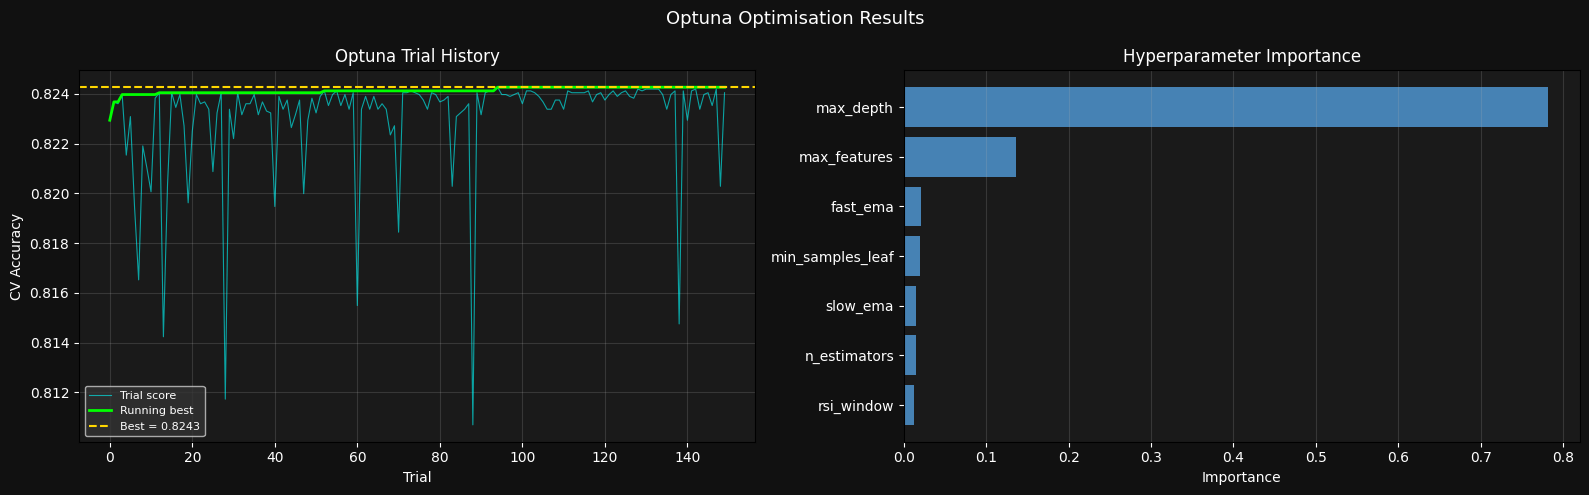

In [29]:
# ── Optuna Visualisation ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.patch.set_facecolor("#111111")

# Trial history
trial_vals = [t.value for t in study.trials if t.value is not None]
ax = axes[0]
ax.set_facecolor("#1a1a1a")
ax.plot(trial_vals, color="cyan", lw=0.8, alpha=0.6, label="Trial score")
running_best = pd.Series(trial_vals).cummax()
ax.plot(running_best, color="lime", lw=2, label="Running best")
ax.axhline(study.best_value, color="gold", lw=1.5, ls="--",
           label=f"Best = {study.best_value:.4f}")
ax.set_title("Optuna Trial History", color="white")
ax.set_xlabel("Trial", color="white"); ax.set_ylabel("CV Accuracy", color="white")
ax.tick_params(colors="white"); ax.legend(facecolor="#333", labelcolor="white", fontsize=8)
ax.grid(alpha=0.2)

# Parameter importance (top features)
try:
    importances = optuna.importance.get_param_importances(study)
    params_names = list(importances.keys())[:8]
    params_vals  = [importances[k] for k in params_names]
    ax2 = axes[1]
    ax2.set_facecolor("#1a1a1a")
    bars = ax2.barh(params_names[::-1], params_vals[::-1], color="steelblue")
    ax2.set_title("Hyperparameter Importance", color="white")
    ax2.set_xlabel("Importance", color="white")
    ax2.tick_params(colors="white")
    ax2.grid(alpha=0.2, axis="x")
except Exception:
    axes[1].set_visible(False)

plt.suptitle("Optuna Optimisation Results", color="white", fontsize=13)
plt.tight_layout()
plt.savefig("optuna_results.png", dpi=130, bbox_inches="tight", facecolor="#111111")
plt.show()


## 🌳 Train Final Random Forest Model

In [30]:
# ── Rebuild dataset with best params ─────────────────────────
BEST_FAST_EMA   = best["fast_ema"]
BEST_SLOW_EMA   = best["slow_ema"]
BEST_RSI_WIN    = best["rsi_window"]

print(f"Rebuilding indicators: FastEMA={BEST_FAST_EMA}, SlowEMA={BEST_SLOW_EMA}, RSI={BEST_RSI_WIN}")

base_cols = ["open","high","low","close","volume"]
df_final = df_signal[base_cols].copy()
df_final = add_indicators(df_final, BEST_FAST_EMA, BEST_SLOW_EMA, BEST_RSI_WIN)

# Re-attach HMM + pivot
df_final = df_final.join(df_hmm[[c for c in df_hmm.columns
                                  if c.startswith("hmm") or c in
                                  ["dist_to_resist","dist_to_support",
                                   "near_resist","near_support"]]], how="left")
df_final["bull_regime"] = df_final["close"] > df_final[f"ema_{BEST_SLOW_EMA}"]
df_final["ema_fast"]    = df_final[f"ema_{BEST_FAST_EMA}"]
df_final["ema_slow"]    = df_final[f"ema_{BEST_SLOW_EMA}"]

# Features & Labels
X_all  = build_features(df_final)
y_all  = make_forward_return_labels(df_final, FORWARD_BARS, LABEL_THRESH)
y_all  = y_all.reindex(X_all.index).dropna()
X_all  = X_all.reindex(y_all.index).dropna()
y_all  = y_all.reindex(X_all.index)

# Train / Test split (80/20 time-ordered)
split    = int(len(X_all) * 0.8)
X_train, X_test = X_all.iloc[:split], X_all.iloc[split:]
y_train, y_test = y_all.iloc[:split], y_all.iloc[split:]

# Scale
scaler_final = StandardScaler()
X_train_s    = scaler_final.fit_transform(X_train)
X_test_s     = scaler_final.transform(X_test)

# Final model
rf_final = RandomForestClassifier(
    n_estimators     = best.get("n_estimators",    200),
    max_depth        = best.get("max_depth",          6),
    min_samples_leaf = best.get("min_samples_leaf",   5),
    max_features     = best.get("max_features",  "sqrt"),
    n_jobs           = -1,
    random_state     = 42,
)
rf_final.fit(X_train_s, y_train)

train_acc = rf_final.score(X_train_s, y_train)
test_acc  = rf_final.score(X_test_s,  y_test)
print(f"\n✅ Final RF trained:")
print(f"   Train accuracy : {train_acc:.4f}")
print(f"   Test  accuracy : {test_acc:.4f}")
print(f"\nClassification Report (Test Set):")
print(classification_report(y_test, rf_final.predict(X_test_s)))


Rebuilding indicators: FastEMA=48, SlowEMA=176, RSI=19

✅ Final RF trained:
   Train accuracy : 0.8554
   Test  accuracy : 0.7727

Classification Report (Test Set):
              precision    recall  f1-score   support

           0       0.77      1.00      0.87      2515
           1       0.00      0.00      0.00       740

    accuracy                           0.77      3255
   macro avg       0.39      0.50      0.44      3255
weighted avg       0.60      0.77      0.67      3255



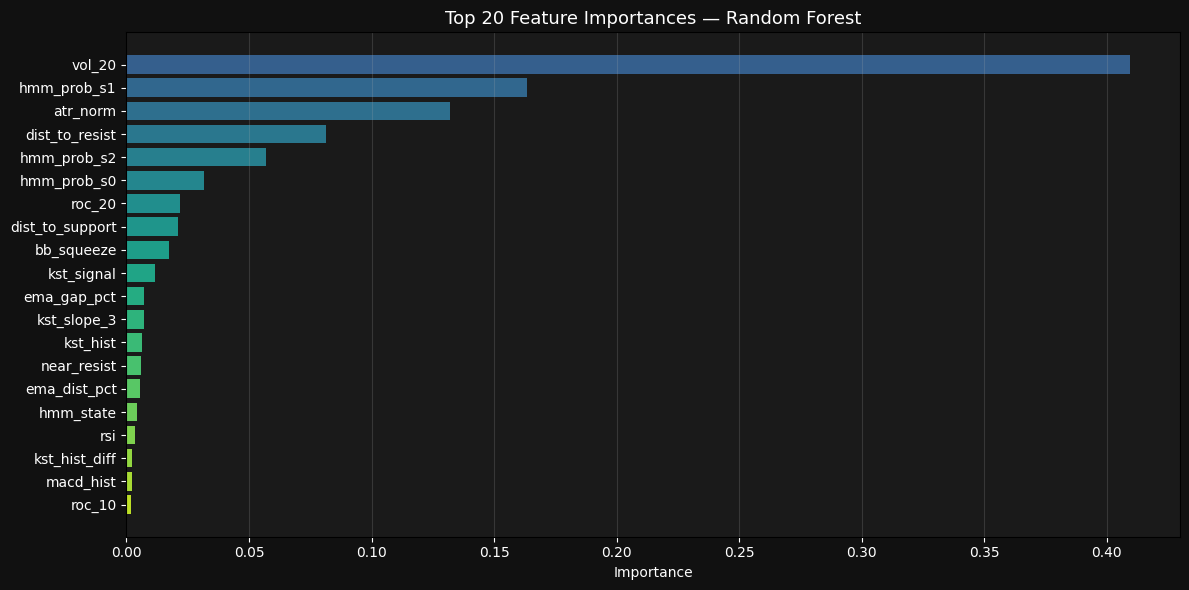

vol_20            0.4095
hmm_prob_s1       0.1637
atr_norm          0.1320
dist_to_resist    0.0815
hmm_prob_s2       0.0571
hmm_prob_s0       0.0318
roc_20            0.0219
dist_to_support   0.0212
bb_squeeze        0.0172
kst_signal        0.0115


In [31]:
# ── Feature Importance Plot ───────────────────────────────────
feat_imp = pd.Series(rf_final.feature_importances_,
                     index=X_train.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#111111")
ax.set_facecolor("#1a1a1a")
top_n = 20
colors = plt.cm.viridis(np.linspace(0.3, 0.9, top_n))
ax.barh(feat_imp.head(top_n).index[::-1],
        feat_imp.head(top_n).values[::-1], color=colors[::-1])
ax.set_title(f"Top {top_n} Feature Importances — Random Forest", color="white", fontsize=13)
ax.set_xlabel("Importance", color="white")
ax.tick_params(colors="white")
ax.grid(alpha=0.2, axis="x")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=130, bbox_inches="tight", facecolor="#111111")
plt.show()
print(feat_imp.head(10).to_string())


## 🚦 ML-Filtered Signal Generation

In [32]:
def apply_ml_filter(df: pd.DataFrame, model, scaler,
                    features_df: pd.DataFrame,
                    proba_threshold: float = 0.55) -> pd.DataFrame:
    """
    Apply trained RF model as a gate on KST signals.
    Only passes signals where RF P(positive) >= proba_threshold.
    """
    df = df.copy()
    X  = scaler.transform(features_df.reindex(df.index).dropna())
    proba = pd.Series(
        model.predict_proba(X)[:, 1],
        index=features_df.reindex(df.index).dropna().index
    )
    ml_approved = proba >= proba_threshold
    df["rf_proba"]       = proba
    df["ml_approved"]    = ml_approved
    df["long_signal_ml"] = df.get("long_signal", False) & ml_approved.reindex(df.index).fillna(False)
    df["short_signal_ml"]= df.get("short_signal", False) & ~ml_approved.reindex(df.index).fillna(True)
    return df


# Generate base signals on df_final
df_final = generate_kst_signals(df_final, use_hmm_filter=True)

# Apply ML filter
PROBA_THRESHOLD = 0.55    # Tune this (0.5–0.65 typical range)
df_final = apply_ml_filter(df_final, rf_final, scaler_final,
                            X_all, proba_threshold=PROBA_THRESHOLD)

print("Signal comparison:")
print(f"  Base KST+EMA Longs  : {df_final['long_signal'].sum()}")
print(f"  ML-filtered  Longs  : {df_final['long_signal_ml'].sum()}")
print(f"  Base KST+EMA Shorts : {df_final['short_signal'].sum()}")
print(f"  ML-filtered  Shorts : {df_final['short_signal_ml'].sum()}")


Signal comparison:
  Base KST+EMA Longs  : 93
  ML-filtered  Longs  : 0
  Base KST+EMA Shorts : 62
  ML-filtered  Shorts : 61


## 📊 Backtesting Engine

In [33]:
from dataclasses import dataclass as _dc

@_dc
class Trade:
    entry_date:       object
    exit_date:        object
    direction:        str
    entry_price:      float
    exit_price:       float
    pnl:              float
    pnl_pct:          float
    capital_at_entry: float


def run_backtest(df: pd.DataFrame,
                 long_col:  str = "long_signal",
                 short_col: str = "short_signal",
                 params: BacktestParams = BT_PARAMS) -> dict:
    """
    Vectorized next-bar execution backtest.
    One position at a time (long or short), no pyramiding.
    Exits on opposite signal.
    """
    df_bt     = df.dropna(subset=["close"]).copy()
    capital   = params.initial_capital
    position  = None
    entry_bar = None
    entry_px  = 0.0
    trades    = []

    prices = df_bt["close"].values
    longs  = df_bt[long_col].fillna(False).values
    shorts = df_bt[short_col].fillna(False).values
    dates  = df_bt.index
    cs     = params.commission_pct + params.slippage_pct

    for i in range(1, len(df_bt)):
        px = prices[i]

        # ── Exits ──────────────────────────────────────────────────
        if position == "long" and shorts[i-1]:
            pnl_pct = (px / entry_px - 1) - 2*cs
            pnl     = capital * params.position_size_pct * pnl_pct
            trades.append(Trade(dates[entry_bar], dates[i], "long",
                                entry_px, px, pnl, pnl_pct, capital))
            capital  += pnl; position = None

        elif position == "short" and longs[i-1]:
            pnl_pct = (entry_px / px - 1) - 2*cs
            pnl     = capital * params.position_size_pct * pnl_pct
            trades.append(Trade(dates[entry_bar], dates[i], "short",
                                entry_px, px, pnl, pnl_pct, capital))
            capital  += pnl; position = None

        # ── Entries ─────────────────────────────────────────────────
        if position is None:
            if longs[i-1]:
                position, entry_bar, entry_px = "long",  i, px
            elif shorts[i-1]:
                position, entry_bar, entry_px = "short", i, px

    # Close open position at end
    if position is not None:
        px = prices[-1]
        pnl_pct = (px/entry_px - 1 if position=="long" else entry_px/px - 1) - 2*cs
        pnl     = capital * params.position_size_pct * pnl_pct
        trades.append(Trade(dates[entry_bar], dates[-1], position,
                            entry_px, px, pnl, pnl_pct, capital))
        capital += pnl

    return _calc_stats(trades, params.initial_capital, capital, df_bt)


def _calc_stats(trades, init_cap, final_cap, df):
    if not trades:
        return {"error": "No trades generated."}
    td   = pd.DataFrame([t.__dict__ for t in trades])
    wins = td[td["pnl"] > 0]; loss = td[td["pnl"] <= 0]

    equity   = pd.Series([init_cap] + list((pd.Series([init_cap] +
                         [t.pnl for t in trades])).cumsum()[1:]),
                         index=[td["entry_date"].iloc[0]] + list(td["exit_date"]))

    roll_max = equity.cummax()
    max_dd   = ((equity - roll_max) / roll_max).min()
    sharpe   = (td["pnl_pct"].mean() / td["pnl_pct"].std() * np.sqrt(252)
                if td["pnl_pct"].std() > 0 else 0)
    bh       = (df["close"].iloc[-1] / df["close"].iloc[0] - 1) * 100

    return {
        "initial_capital":   init_cap,
        "final_capital":     round(final_cap, 2),
        "net_pnl":           round(final_cap - init_cap, 2),
        "total_return_pct":  round((final_cap/init_cap - 1)*100, 2),
        "buy_hold_pct":      round(bh, 2),
        "total_trades":      len(trades),
        "win_rate_pct":      round(len(wins)/len(trades)*100, 2),
        "avg_win_pct":       round(wins["pnl_pct"].mean()*100, 3) if len(wins) else 0,
        "avg_loss_pct":      round(loss["pnl_pct"].mean()*100, 3) if len(loss) else 0,
        "profit_factor":     round(wins["pnl"].sum()/abs(loss["pnl"].sum()), 2)
                             if loss["pnl"].sum()!=0 else float("inf"),
        "max_drawdown_pct":  round(max_dd*100, 2),
        "sharpe_ratio":      round(sharpe, 3),
        "trade_df":          td,
        "equity_series":     equity,
    }


print("✅ Backtesting engine ready.")


✅ Backtesting engine ready.


In [34]:
# ── Run all three strategy variants ──────────────────────────
print("Running backtests …\n")

# 1) Base: KST + EMA only
stats_base = run_backtest(df_final, "long_signal",    "short_signal")

# 2) HMM-filtered
df_hmm_sig = generate_kst_signals(df_final.copy(), use_hmm_filter=True)
stats_hmm  = run_backtest(df_hmm_sig, "long_signal",  "short_signal")

# 3) ML-filtered (RF + HMM)
stats_ml   = run_backtest(df_final, "long_signal_ml", "short_signal_ml")

def print_stats(name, s):
    print(f"{'─'*50}")
    print(f" {name}")
    print(f"{'─'*50}")
    for k, v in s.items():
        if k not in ("trade_df","equity_series"):
            print(f"  {k:<25} {v}")
    print()

print_stats("1. Base KST + EMA",         stats_base)
print_stats("2. KST + EMA + HMM Filter", stats_hmm)
print_stats("3. KST + EMA + HMM + RF",   stats_ml)


Running backtests …

──────────────────────────────────────────────────
 1. Base KST + EMA
──────────────────────────────────────────────────
  initial_capital           10000.0
  final_capital             11498.91
  net_pnl                   1498.91
  total_return_pct          14.99
  buy_hold_pct              -22.37
  total_trades              44
  win_rate_pct              36.36
  avg_win_pct               3.315
  avg_loss_pct              -1.305
  profit_factor             1.38
  max_drawdown_pct          -14.29
  sharpe_ratio              1.68

──────────────────────────────────────────────────
 2. KST + EMA + HMM Filter
──────────────────────────────────────────────────
  initial_capital           10000.0
  final_capital             11498.91
  net_pnl                   1498.91
  total_return_pct          14.99
  buy_hold_pct              -22.37
  total_trades              44
  win_rate_pct              36.36
  avg_win_pct               3.315
  avg_loss_pct              -1.305
  p

## 📈 Results Dashboard

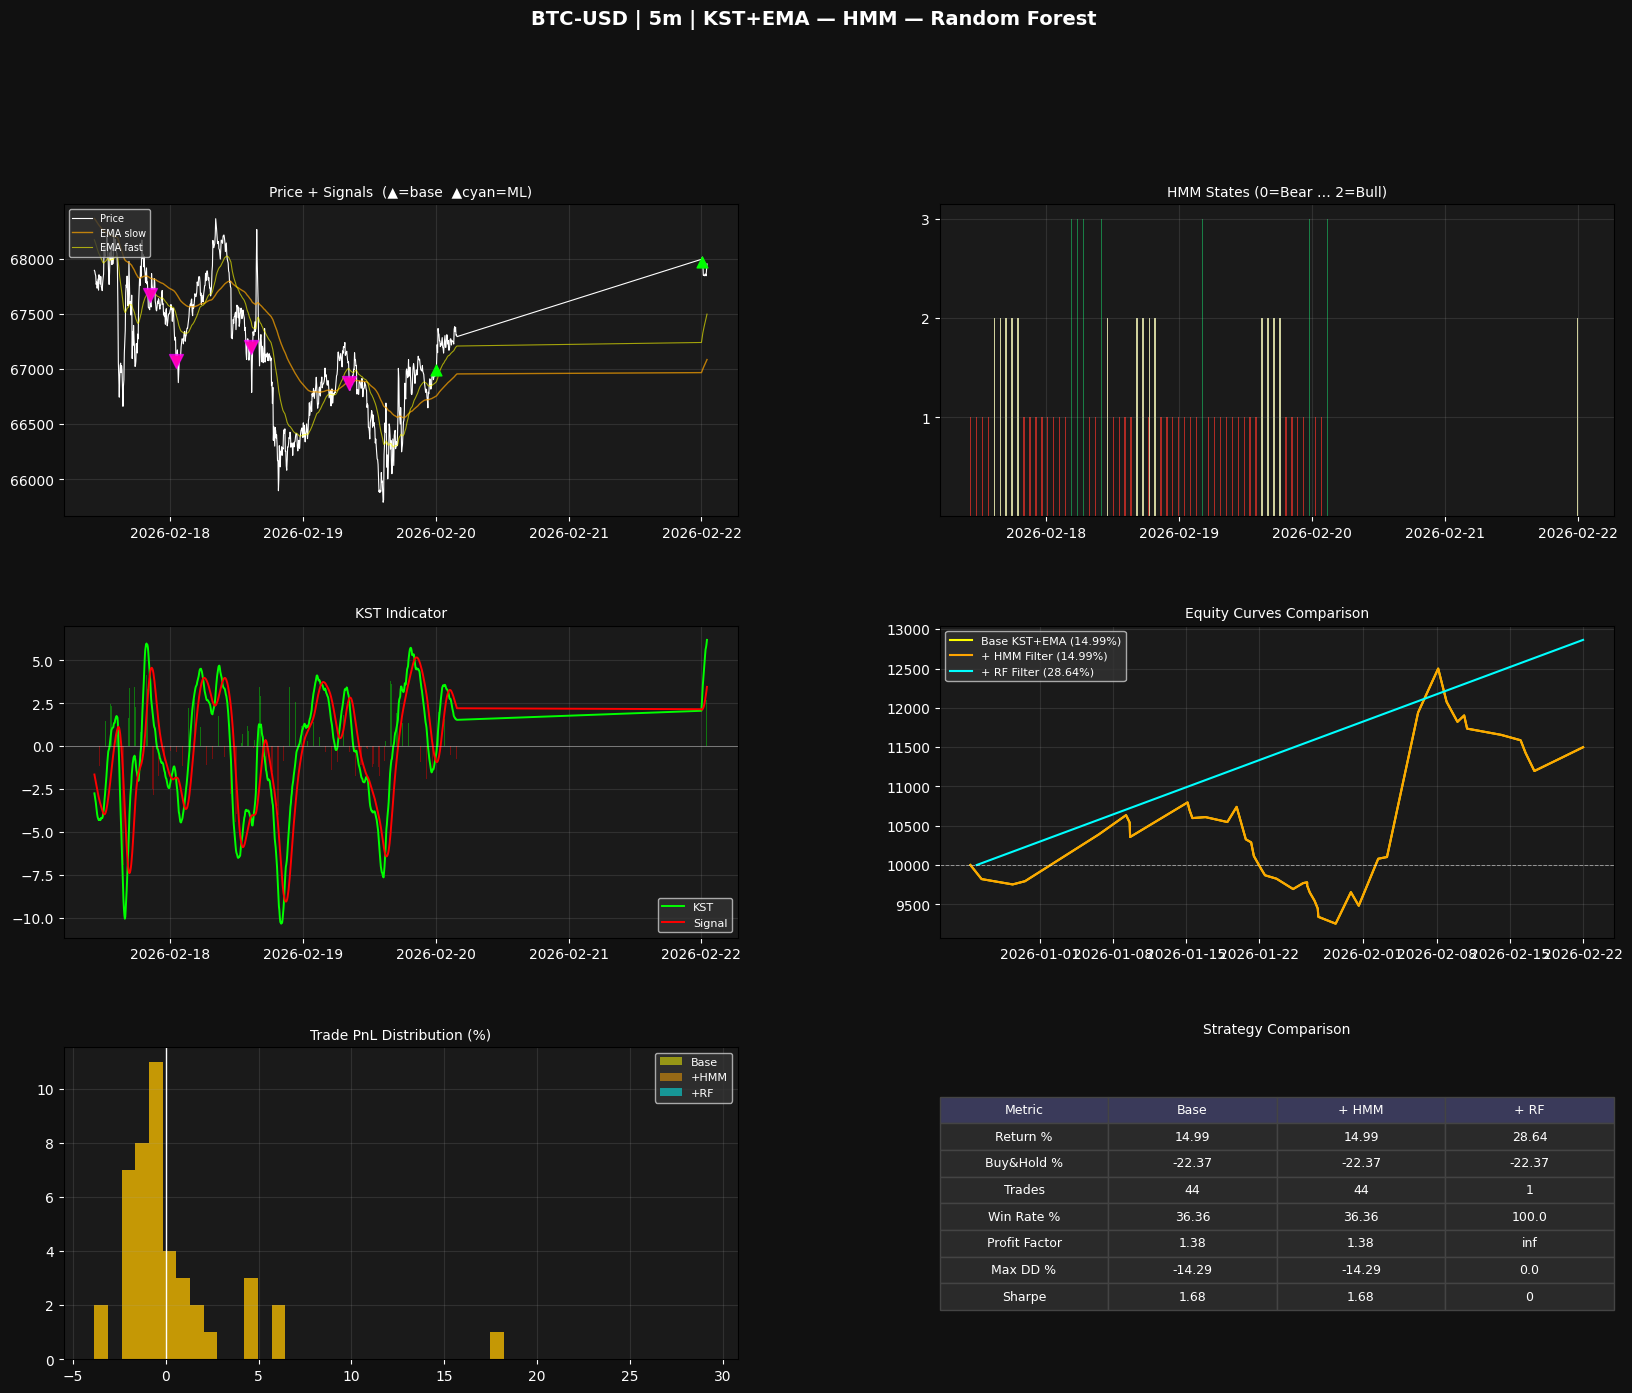

✅ Dashboard saved → strategy_dashboard.png


In [35]:
def plot_dashboard(df: pd.DataFrame, stats_dict: dict, sample: int = 800):
    """
    3×2 dashboard:
      [0,0] Price + signals + pivot levels
      [0,1] HMM regime bar
      [1,0] KST indicator
      [1,1] Equity curves comparison
      [2,0] Trade PnL distribution
      [2,1] Metrics comparison table
    """
    df_p = df.dropna(subset=["kst"]).iloc[-sample:]
    fig  = plt.figure(figsize=(20, 15))
    fig.patch.set_facecolor("#111111")
    gs   = gridspec.GridSpec(3, 2, figure=fig, hspace=0.35, wspace=0.3)

    BG = "#1a1a1a"

    # ─── Panel A: Price ─────────────────────────────────────────
    axA = fig.add_subplot(gs[0, 0])
    axA.set_facecolor(BG)
    axA.plot(df_p.index, df_p["close"], color="white", lw=0.8, label="Price")
    if "ema_slow" in df_p: axA.plot(df_p.index, df_p["ema_slow"], color="orange",
                                     lw=1, alpha=0.7, label=f"EMA slow")
    if "ema_fast" in df_p: axA.plot(df_p.index, df_p["ema_fast"], color="yellow",
                                     lw=0.8, alpha=0.6, label=f"EMA fast")
    if "resist" in df_p:
        axA.plot(df_p.index, df_p["resist"], color="red",   lw=0.7, ls="--", alpha=0.6, label="1h Resist")
        axA.plot(df_p.index, df_p["support"],color="lime",  lw=0.7, ls="--", alpha=0.6, label="1h Support")

    ls = df_p[df_p["long_signal"]]
    ss = df_p[df_p["short_signal"]]
    axA.scatter(ls.index, ls["close"], marker="^", color="lime",  s=60, zorder=5)
    axA.scatter(ss.index, ss["close"], marker="v", color="red",   s=60, zorder=5)
    if "long_signal_ml" in df_p:
        ls_ml = df_p[df_p["long_signal_ml"]]
        ss_ml = df_p[df_p["short_signal_ml"]]
        axA.scatter(ls_ml.index, ls_ml["close"], marker="^", color="cyan",    s=100, zorder=6, alpha=0.7)
        axA.scatter(ss_ml.index, ss_ml["close"], marker="v", color="magenta", s=100, zorder=6, alpha=0.7)

    axA.set_title("Price + Signals  (▲=base  ▲cyan=ML)", color="white", fontsize=10)
    axA.legend(facecolor="#333", labelcolor="white", fontsize=7, loc="upper left")
    axA.tick_params(colors="white"); axA.grid(alpha=0.15)

    # ─── Panel B: HMM states ────────────────────────────────────
    axB = fig.add_subplot(gs[0, 1])
    axB.set_facecolor(BG)
    palette = plt.cm.RdYlGn(np.linspace(0.1, 0.9, HMM_N_STATES))
    if "hmm_state" in df_p.columns:
        states = df_p["hmm_state"].fillna(0).astype(int).values
        axB.bar(df_p.index, states + 1,
                color=[palette[s] for s in states], alpha=0.8, width=0.0008)
    axB.set_title(f"HMM States (0=Bear … {HMM_N_STATES-1}=Bull)", color="white", fontsize=10)
    axB.set_yticks(range(1, HMM_N_STATES+1))
    axB.tick_params(colors="white"); axB.grid(alpha=0.15)

    # ─── Panel C: KST ───────────────────────────────────────────
    axC = fig.add_subplot(gs[1, 0])
    axC.set_facecolor(BG)
    axC.plot(df_p.index, df_p["kst"],        color="lime", lw=1.4, label="KST")
    axC.plot(df_p.index, df_p["kst_signal"], color="red",  lw=1.4, label="Signal")
    axC.bar(df_p.index,  df_p["kst_hist"],
            color=["lime" if v >= 0 else "red" for v in df_p["kst_hist"]],
            alpha=0.4, width=0.0008)
    axC.axhline(0, color="white", lw=0.5, alpha=0.5)
    axC.set_title("KST Indicator", color="white", fontsize=10)
    axC.legend(facecolor="#333", labelcolor="white", fontsize=8)
    axC.tick_params(colors="white"); axC.grid(alpha=0.15)

    # ─── Panel D: Equity curves ──────────────────────────────────
    axD = fig.add_subplot(gs[1, 1])
    axD.set_facecolor(BG)
    for (label, stats, col) in [
        ("Base KST+EMA", stats_base, "yellow"),
        ("+ HMM Filter", stats_hmm,  "orange"),
        ("+ RF Filter",  stats_ml,   "cyan"),
    ]:
        if "equity_series" in stats:
            eq = stats["equity_series"]
            axD.plot(eq.index, eq.values, color=col, lw=1.5,
                     label=f"{label} ({stats['total_return_pct']}%)")
    axD.axhline(BT_PARAMS.initial_capital, color="white", lw=0.7, ls="--", alpha=0.5)
    axD.set_title("Equity Curves Comparison", color="white", fontsize=10)
    axD.legend(facecolor="#333", labelcolor="white", fontsize=8)
    axD.tick_params(colors="white"); axD.grid(alpha=0.15)

    # ─── Panel E: PnL distribution ──────────────────────────────
    axE = fig.add_subplot(gs[2, 0])
    axE.set_facecolor(BG)
    for (label, stats, col) in [
        ("Base",    stats_base, "yellow"),
        ("+HMM",    stats_hmm,  "orange"),
        ("+RF",     stats_ml,   "cyan"),
    ]:
        if "trade_df" in stats and len(stats["trade_df"]) > 0:
            axE.hist(stats["trade_df"]["pnl_pct"]*100, bins=30,
                     alpha=0.5, color=col, label=label)
    axE.axvline(0, color="white", lw=1)
    axE.set_title("Trade PnL Distribution (%)", color="white", fontsize=10)
    axE.legend(facecolor="#333", labelcolor="white", fontsize=8)
    axE.tick_params(colors="white"); axE.grid(alpha=0.15)

    # ─── Panel F: Metrics table ──────────────────────────────────
    axF = fig.add_subplot(gs[2, 1])
    axF.set_facecolor(BG); axF.axis("off")
    metrics = ["total_return_pct","buy_hold_pct","total_trades",
               "win_rate_pct","profit_factor","max_drawdown_pct","sharpe_ratio"]
    labels_m = ["Return %","Buy&Hold %","Trades","Win Rate %",
                "Profit Factor","Max DD %","Sharpe"]
    rows = []
    for m, lbl in zip(metrics, labels_m):
        rows.append([lbl,
                     stats_base.get(m,"—"),
                     stats_hmm.get(m,"—"),
                     stats_ml.get(m,"—")])
    table = axF.table(cellText=rows,
                      colLabels=["Metric","Base","+ HMM","+ RF"],
                      loc="center", cellLoc="center")
    table.auto_set_font_size(False); table.set_fontsize(9)
    table.scale(1, 1.6)
    for (r,c), cell in table.get_celld().items():
        cell.set_facecolor("#2a2a2a" if r > 0 else "#3a3a5a")
        cell.set_text_props(color="white")
        cell.set_edgecolor("#444444")
    axF.set_title("Strategy Comparison", color="white", fontsize=10, pad=10)

    fig.suptitle(f"{TICKER} | {SIGNAL_TF} | KST+EMA — HMM — Random Forest",
                 color="white", fontsize=14, fontweight="bold", y=1.01)
    plt.savefig("strategy_dashboard.png", dpi=140, bbox_inches="tight",
                facecolor="#111111")
    plt.show()
    print("✅ Dashboard saved → strategy_dashboard.png")


plot_dashboard(df_final, {"base": stats_base, "hmm": stats_hmm, "ml": stats_ml})


## 🗒️ Trade Log

In [36]:
# ── ML-filtered trade log ─────────────────────────────────────
if "trade_df" in stats_ml and len(stats_ml["trade_df"]) > 0:
    td = stats_ml["trade_df"].copy()
    td["pnl_pct"] = (td["pnl_pct"] * 100).round(3)
    td["pnl"]     = td["pnl"].round(2)
    display_cols  = ["entry_date","exit_date","direction",
                     "entry_price","exit_price","pnl","pnl_pct"]
    print(f"ML-filtered strategy — {len(td)} trades\n")
    print(td[display_cols].tail(20).to_string(index=False))
else:
    print("No trades generated — try adjusting PROBA_THRESHOLD or date range.")


ML-filtered strategy — 1 trades

         entry_date           exit_date direction  entry_price  exit_price       pnl  pnl_pct
2025-12-25 22:55:00 2026-02-22 01:00:00     short   87625.0625  67955.7969 2864.4200  28.6440


## 💾 Save Results

In [37]:
import pickle, os

# Save trade logs
for name, stats in [("base", stats_base), ("hmm", stats_hmm), ("ml", stats_ml)]:
    if "trade_df" in stats:
        fname = f"trades_{name}.csv"
        stats["trade_df"].to_csv(fname, index=False)
        print(f"✅ Saved {fname}")

# Save trained RF model + scaler
with open("rf_model.pkl", "wb") as f:
    pickle.dump({"model": rf_final, "scaler": scaler_final,
                 "best_params": best, "features": list(X_all.columns)}, f)
print("✅ Saved rf_model.pkl")

# Colab: download files automatically if running in Colab
try:
    from google.colab import files
    for fname in ["strategy_dashboard.png","hmm_regimes.png",
                  "optuna_results.png","feature_importance.png",
                  "trades_ml.csv","rf_model.pkl"]:
        if os.path.exists(fname):
            files.download(fname)
    print("✅ Files downloaded via Colab.")
except ImportError:
    print("(Not in Colab — files saved to current directory.)")


✅ Saved trades_base.csv
✅ Saved trades_hmm.csv
✅ Saved trades_ml.csv
✅ Saved rf_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Files downloaded via Colab.
